# CSRNet Crowd Counting — FIXED v2 (Option 2: Extend and Innovate)

**Project:** Single-Image Crowd Counting for Public Gatherings Using Deep Learning
**Authors:** Alaa Riyad, Moamen Abouzaid, Omar Joudeh
**Course:** COE486 — Computer Vision

## What changed from v1
The previous version had a training-stability bug: ground-truth density values were ~0.04 per pixel, making MSE loss values ~0.0006, making gradients too small for Adam to update weights. The fix is the **standard CSRNet trick**: multiply ground-truth density values by 100 during training, divide predictions by 100 at inference.

## Project framing — Option 2 (Extend and Innovate)
We extend CSRNet (Li et al., 2018) along three axes:
1. **Geometry-adaptive density-map generation** — k-NN based per-head Gaussian sigma, faithful to the original paper.
2. **Improved augmentation pipeline** — random crop, flip, brightness, contrast.
3. **Stable training recipe** — density rescaling + StepLR + gradient clipping.

We then evaluate cross-part performance (Part A: highly congested; Part B: sparser) and provide error analysis segmented by crowd-density bucket.

## Workflow
1. Run sections 1–7 once.
2. **Train Part B first** (it's easier — confirms the pipeline works) → run sections 8–9.
3. **Train Part A** → re-run sections 8–9 with `PART = "part_A_final"`.
4. Run section 10 (comparison table) and section 11 (demo).

---
## 1. Setup

In [ ]:
# Check GPU
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU.")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Reproducibility — set ALL seeds before anything else
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


In [ ]:
# Project paths
import os

project_path = "/content/drive/MyDrive/crowd-counting-csrnet"

folders = [
    "data", "data/raw", "data/processed",
    "models", "utils",
    "checkpoints", "checkpoints/partA", "checkpoints/partB",
    "results", "results/plots", "results/predictions",
    "demo",
]
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)
print("Project path:", project_path)

Project path: /content/drive/MyDrive/crowd-counting-csrnet


In [ ]:
# Install dependencies
!pip install -q scipy h5py matplotlib pillow opencv-python tqdm scikit-learn

In [ ]:
# Imports
import os
import sys
import time
import gc
import shutil

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree
from sklearn.model_selection import train_test_split

import cv2
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

print("All libraries imported.")

All libraries imported.


In [ ]:
# CRITICAL: density-scaling factor for stable training.
# Ground-truth density values get multiplied by this during training,
# and model outputs get divided by this at inference. This is the standard
# CSRNet recipe — without it, MSE loss is too small and the model can't learn.
DENSITY_SCALE = 100.0
print(f"Density scale factor: {DENSITY_SCALE}")

Density scale factor: 100.0


---
## 2. Dataset — ShanghaiTech (Part A + Part B)

If your teammate already has the dataset and density maps on Drive, **skip the download cells** — just verify they exist.

In [ ]:
# Download ShanghaiTech (skip if already done by another team member)
zip_path = os.path.join(project_path, "data/raw/ShanghaiTech_Crowd_Counting_Dataset.zip")
extract_path = os.path.join(project_path, "data/raw/ShanghaiTech")

if not os.path.exists(extract_path):
    %cd /content/drive/MyDrive/crowd-counting-csrnet/data/raw
    !wget -O ShanghaiTech_Crowd_Counting_Dataset.zip "https://www.dropbox.com/scl/fi/dkj5kulc9zj0rzesslck8/ShanghaiTech_Crowd_Counting_Dataset.zip?rlkey=ymbcj50ac04uvqn8p49j9af5f&dl=1"
    !unzip -q ShanghaiTech_Crowd_Counting_Dataset.zip -d ShanghaiTech
    print("Dataset extracted.")
else:
    print("Dataset already exists.")

Dataset already exists.


In [ ]:
# Verify
for part in ["part_A_final", "part_B_final"]:
    base = os.path.join(project_path, "data/raw/ShanghaiTech", part)
    for split in ["train_data", "test_data"]:
        img_dir = os.path.join(base, split, "images")
        gt_dir = os.path.join(base, split, "ground_truth")
        n_img = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
        n_gt = len(os.listdir(gt_dir)) if os.path.exists(gt_dir) else 0
        print(f"{part} / {split}: {n_img} images, {n_gt} GT files")

part_A_final / train_data: 300 images, 300 GT files
part_A_final / test_data: 182 images, 182 GT files
part_B_final / train_data: 400 images, 400 GT files
part_B_final / test_data: 316 images, 316 GT files


---
## 3. Density map generation

Uses **geometry-adaptive Gaussian** for Part A (k-NN based sigma per head — original paper recipe) and **fixed sigma** for Part B (sparser scenes). The adaptive kernel is implemented with a fast local-patch approach (~50× faster than naive full-image filtering).

In [ ]:
def load_points_from_mat(mat_path):
    mat = sio.loadmat(mat_path)
    return mat["image_info"][0, 0][0, 0][0]


def create_density_map_fixed(image_shape, points, sigma=15):
    """Fixed-sigma Gaussian. Used for Part B."""
    h, w = image_shape[0], image_shape[1]
    density = np.zeros((h, w), dtype=np.float32)
    for p in points:
        x, y = int(p[0]), int(p[1])
        if 0 <= x < w and 0 <= y < h:
            density[y, x] = 1.0
    density = gaussian_filter(density, sigma=sigma)
    if density.sum() > 0:
        density = density * (len(points) / density.sum())
    return density.astype(np.float32)


def create_density_map_adaptive(image_shape, points, k=4, beta=0.3):
    """
    Geometry-adaptive Gaussian for Part A. Sigma per head = beta * mean
    distance to k-1 nearest neighbours. Optimized: blurs only a local
    patch (radius 3*sigma) per head instead of the full image.
    """
    h, w = image_shape[0], image_shape[1]
    density = np.zeros((h, w), dtype=np.float32)
    if len(points) == 0:
        return density

    tree = KDTree(points.copy(), leafsize=2048)
    distances, _ = tree.query(points, k=min(k, len(points)))

    for i, p in enumerate(points):
        x, y = int(p[0]), int(p[1])
        if not (0 <= x < w and 0 <= y < h):
            continue

        if len(points) > 1:
            avg_dist = distances[i][1:].mean()
            sigma = beta * avg_dist
        else:
            sigma = np.average(np.array([h, w])) / 4.0
        sigma = max(sigma, 1.0)

        radius = int(3 * sigma) + 1
        x_min, x_max = max(0, x - radius), min(w, x + radius + 1)
        y_min, y_max = max(0, y - radius), min(h, y + radius + 1)

        yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
        gauss = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
        gauss /= gauss.sum() + 1e-10
        density[y_min:y_max, x_min:x_max] += gauss.astype(np.float32)

    if density.sum() > 0:
        density = density * (len(points) / density.sum())
    return density.astype(np.float32)


def get_image_number(filename):
    return int(filename.split("_")[1].split(".")[0])

print("Density-map functions defined.")

Density-map functions defined.


In [ ]:
def process_split(image_dir, gt_dir, output_density_dir, output_csv_path,
                  kernel_type="fixed", sigma=15):
    os.makedirs(output_density_dir, exist_ok=True)
    image_files = sorted(
        [f for f in os.listdir(image_dir) if f.lower().endswith(".jpg")],
        key=get_image_number)

    records = []
    for image_file in tqdm(image_files, desc=os.path.basename(output_density_dir)):
        n = get_image_number(image_file)
        img_path = os.path.join(image_dir, image_file)
        gt_path = os.path.join(gt_dir, f"GT_IMG_{n}.mat")
        if not os.path.exists(gt_path):
            continue

        img = np.array(Image.open(img_path).convert("RGB"))
        points = load_points_from_mat(gt_path)

        if kernel_type == "adaptive":
            density = create_density_map_adaptive(img.shape, points)
        else:
            density = create_density_map_fixed(img.shape, points, sigma=sigma)

        out_name = image_file.replace(".jpg", ".npy")
        np.save(os.path.join(output_density_dir, out_name), density)

        records.append({
            "image": image_file,
            "density_map": out_name,
            "actual_count": len(points),
            "density_sum": float(density.sum()),
            "height": img.shape[0],
            "width": img.shape[1],
        })

    df = pd.DataFrame(records)
    df.to_csv(output_csv_path, index=False)
    return df

print("process_split defined.")

process_split defined.


In [ ]:
# Generate density maps using local SSD for speed, then sync to Drive
local_path = "/content/csrnet_local"
os.makedirs(local_path, exist_ok=True)

parts_config = [
    ("part_A_final", "adaptive"),
    ("part_B_final", "fixed"),
]

for part, kernel in parts_config:
    print(f"\n=== {part} ({kernel} kernel) ===")
    raw_base = os.path.join(project_path, "data/raw/ShanghaiTech", part)
    proc_base_local = os.path.join(local_path, "processed", part)
    proc_base_drive = os.path.join(project_path, "data/processed", part)

    for split in ["train_data", "test_data"]:
        img_dir = os.path.join(raw_base, split, "images")
        gt_dir = os.path.join(raw_base, split, "ground_truth")
        density_dir_local = os.path.join(proc_base_local, split, "density_maps")
        csv_path_local = os.path.join(proc_base_local, f"{split.replace('_data', '')}_counts.csv")

        csv_path_drive = os.path.join(proc_base_drive, f"{split.replace('_data', '')}_counts.csv")
        if os.path.exists(csv_path_drive):
            print(f"  {split}: already on Drive, skipping.")
            continue

        process_split(img_dir, gt_dir, density_dir_local, csv_path_local,
                      kernel_type=kernel, sigma=15)

        density_dir_drive = os.path.join(proc_base_drive, split, "density_maps")
        os.makedirs(density_dir_drive, exist_ok=True)
        print(f"  Copying {split} to Drive...")
        shutil.copytree(density_dir_local, density_dir_drive, dirs_exist_ok=True)
        shutil.copy(csv_path_local, csv_path_drive)

print("\nDone.")


=== part_A_final (adaptive kernel) ===
  train_data: already on Drive, skipping.
  test_data: already on Drive, skipping.

=== part_B_final (fixed kernel) ===
  train_data: already on Drive, skipping.
  test_data: already on Drive, skipping.

Done.


---
## 4. Dataset class with augmentation **and density scaling**

In [ ]:
class CrowdCountingDataset(Dataset):
    def __init__(self, csv_path, image_dir, density_dir,
                 crop_size=(384, 512), output_downscale=8, augment=False,
                 density_scale=DENSITY_SCALE):
        """
        density_scale: ground-truth density values are multiplied by this
                       so MSE loss has meaningful magnitude (~1.0 not ~0.001).
                       At inference, model outputs are divided by this same
                       factor to get back to real counts.
        """
        self.data = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.density_dir = density_dir
        self.crop_size = crop_size
        self.output_downscale = output_downscale
        self.augment = augment
        self.density_scale = density_scale

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.data)

    def _resize_density_preserve_count(self, density, new_h, new_w):
        original = density.sum()
        resized = cv2.resize(density, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        if resized.sum() > 0 and original > 0:
            resized = resized * (original / resized.sum())
        return resized.astype(np.float32)

    def _random_crop(self, image_np, density):
        H, W = image_np.shape[:2]
        crop_h, crop_w = self.crop_size
        if H < crop_h or W < crop_w:
            scale = max(crop_h / H, crop_w / W) * 1.05
            new_H, new_W = int(H * scale), int(W * scale)
            image_np = cv2.resize(image_np, (new_W, new_H))
            density = self._resize_density_preserve_count(density, new_H, new_W)
            H, W = new_H, new_W
        top = np.random.randint(0, H - crop_h + 1)
        left = np.random.randint(0, W - crop_w + 1)
        return (image_np[top:top + crop_h, left:left + crop_w],
                density[top:top + crop_h, left:left + crop_w])

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_name = row["image"]
        actual_count = float(row["actual_count"])

        image = Image.open(os.path.join(self.image_dir, image_name)).convert("RGB")
        density = np.load(os.path.join(self.density_dir, row["density_map"])).astype(np.float32)
        image_np = np.array(image)

        if self.augment:
            image_np, density = self._random_crop(image_np, density)
            if np.random.rand() < 0.5:
                image_np = np.ascontiguousarray(image_np[:, ::-1, :])
                density = np.ascontiguousarray(density[:, ::-1])
            image_pil = Image.fromarray(image_np)
            if np.random.rand() < 0.5:
                image_pil = ImageEnhance.Brightness(image_pil).enhance(np.random.uniform(0.8, 1.2))
            if np.random.rand() < 0.5:
                image_pil = ImageEnhance.Contrast(image_pil).enhance(np.random.uniform(0.8, 1.2))
            image_np = np.array(image_pil)
        else:
            crop_h, crop_w = self.crop_size
            image_np = cv2.resize(image_np, (crop_w, crop_h))
            density = self._resize_density_preserve_count(density, crop_h, crop_w)

        out_h = self.crop_size[0] // self.output_downscale
        out_w = self.crop_size[1] // self.output_downscale
        density = self._resize_density_preserve_count(density, out_h, out_w)

        # *** THE KEY FIX: scale up density values for stable training ***
        density = density * self.density_scale

        image_tensor = self.normalize(self.to_tensor(Image.fromarray(image_np)))
        density_tensor = torch.tensor(density, dtype=torch.float32).unsqueeze(0)
        count_tensor = torch.tensor(actual_count, dtype=torch.float32)

        return image_tensor, density_tensor, count_tensor, image_name

print("Dataset class defined (with density scaling).")

Dataset class defined (with density scaling).


---
## 5. CSRNet model

In [ ]:
class CSRNet(nn.Module):
    def __init__(self, load_pretrained=True):
        super().__init__()
        self.frontend_feat = [64, 64, "M", 128, 128, "M",
                              256, 256, 256, "M", 512, 512, 512]
        self.backend_feat = [512, 512, 512, 256, 128, 64]
        self.frontend = self.make_layers(self.frontend_feat)
        self.backend = self.make_layers(self.backend_feat, in_channels=512, dilation=True)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)

        if load_pretrained:
            try:
                vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
                pretrained_dict = vgg.features.state_dict()
                frontend_dict = self.frontend.state_dict()
                pretrained_dict = {
                    k: v for k, v in pretrained_dict.items()
                    if k in frontend_dict and v.size() == frontend_dict[k].size()}
                frontend_dict.update(pretrained_dict)
                self.frontend.load_state_dict(frontend_dict)
                print("Loaded pretrained VGG16.")
            except Exception as e:
                print(f"Couldn't load VGG16: {e}")

        self._initialize_weights()

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output_layer(x)

    def make_layers(self, cfg, in_channels=3, batch_norm=False, dilation=False):
        layers = []
        d_rate = 2 if dilation else 1
        for v in cfg:
            if v == "M":
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                conv2d = nn.Conv2d(in_channels, v, kernel_size=3,
                                   padding=d_rate, dilation=d_rate)
                if batch_norm:
                    layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                else:
                    layers += [conv2d, nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.backend.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        nn.init.normal_(self.output_layer.weight, std=0.01)
        if self.output_layer.bias is not None:
            nn.init.constant_(self.output_layer.bias, 0)

print("CSRNet defined.")

CSRNet defined.


---
## 6. Save .py files for GitHub repo

In [ ]:
# Save the dataset and model code to separate .py files for the GitHub repo
dataset_py = '''import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance

import torch
from torch.utils.data import Dataset
from torchvision import transforms


class CrowdCountingDataset(Dataset):
    def __init__(self, csv_path, image_dir, density_dir,
                 crop_size=(384, 512), output_downscale=8, augment=False,
                 density_scale=100.0):
        self.data = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.density_dir = density_dir
        self.crop_size = crop_size
        self.output_downscale = output_downscale
        self.augment = augment
        self.density_scale = density_scale
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.data)

    def _resize_density_preserve_count(self, density, new_h, new_w):
        original = density.sum()
        resized = cv2.resize(density, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        if resized.sum() > 0 and original > 0:
            resized = resized * (original / resized.sum())
        return resized.astype(np.float32)

    def _random_crop(self, image_np, density):
        H, W = image_np.shape[:2]
        crop_h, crop_w = self.crop_size
        if H < crop_h or W < crop_w:
            scale = max(crop_h / H, crop_w / W) * 1.05
            new_H, new_W = int(H * scale), int(W * scale)
            image_np = cv2.resize(image_np, (new_W, new_H))
            density = self._resize_density_preserve_count(density, new_H, new_W)
            H, W = new_H, new_W
        top = np.random.randint(0, H - crop_h + 1)
        left = np.random.randint(0, W - crop_w + 1)
        return (image_np[top:top + crop_h, left:left + crop_w],
                density[top:top + crop_h, left:left + crop_w])

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_name = row["image"]
        actual_count = float(row["actual_count"])
        image = Image.open(os.path.join(self.image_dir, image_name)).convert("RGB")
        density = np.load(os.path.join(self.density_dir, row["density_map"])).astype(np.float32)
        image_np = np.array(image)

        if self.augment:
            image_np, density = self._random_crop(image_np, density)
            if np.random.rand() < 0.5:
                image_np = np.ascontiguousarray(image_np[:, ::-1, :])
                density = np.ascontiguousarray(density[:, ::-1])
            image_pil = Image.fromarray(image_np)
            if np.random.rand() < 0.5:
                image_pil = ImageEnhance.Brightness(image_pil).enhance(np.random.uniform(0.8, 1.2))
            if np.random.rand() < 0.5:
                image_pil = ImageEnhance.Contrast(image_pil).enhance(np.random.uniform(0.8, 1.2))
            image_np = np.array(image_pil)
        else:
            crop_h, crop_w = self.crop_size
            image_np = cv2.resize(image_np, (crop_w, crop_h))
            density = self._resize_density_preserve_count(density, crop_h, crop_w)

        out_h = self.crop_size[0] // self.output_downscale
        out_w = self.crop_size[1] // self.output_downscale
        density = self._resize_density_preserve_count(density, out_h, out_w)

        density = density * self.density_scale

        image_tensor = self.normalize(self.to_tensor(Image.fromarray(image_np)))
        density_tensor = torch.tensor(density, dtype=torch.float32).unsqueeze(0)
        count_tensor = torch.tensor(actual_count, dtype=torch.float32)
        return image_tensor, density_tensor, count_tensor, image_name
'''

csrnet_py = '''import torch
import torch.nn as nn
import torchvision.models as models


class CSRNet(nn.Module):
    def __init__(self, load_pretrained=True):
        super().__init__()
        self.frontend_feat = [64, 64, "M", 128, 128, "M",
                              256, 256, 256, "M", 512, 512, 512]
        self.backend_feat = [512, 512, 512, 256, 128, 64]
        self.frontend = self.make_layers(self.frontend_feat)
        self.backend = self.make_layers(self.backend_feat, in_channels=512, dilation=True)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)
        if load_pretrained:
            try:
                vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
                pretrained_dict = vgg.features.state_dict()
                frontend_dict = self.frontend.state_dict()
                pretrained_dict = {k: v for k, v in pretrained_dict.items()
                                   if k in frontend_dict and v.size() == frontend_dict[k].size()}
                frontend_dict.update(pretrained_dict)
                self.frontend.load_state_dict(frontend_dict)
            except Exception as e:
                print(f"Couldn't load VGG16: {e}")
        self._initialize_weights()

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output_layer(x)

    def make_layers(self, cfg, in_channels=3, batch_norm=False, dilation=False):
        layers = []
        d_rate = 2 if dilation else 1
        for v in cfg:
            if v == "M":
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                conv2d = nn.Conv2d(in_channels, v, kernel_size=3,
                                   padding=d_rate, dilation=d_rate)
                if batch_norm:
                    layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                else:
                    layers += [conv2d, nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.backend.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        nn.init.normal_(self.output_layer.weight, std=0.01)
        if self.output_layer.bias is not None:
            nn.init.constant_(self.output_layer.bias, 0)
'''

with open(os.path.join(project_path, "utils/dataset.py"), "w") as f:
    f.write(dataset_py)
with open(os.path.join(project_path, "models/csrnet.py"), "w") as f:
    f.write(csrnet_py)
open(os.path.join(project_path, "utils/__init__.py"), "a").close()
open(os.path.join(project_path, "models/__init__.py"), "a").close()
print("Saved utils/dataset.py and models/csrnet.py")

Saved utils/dataset.py and models/csrnet.py


---
## 7. Training utilities **with density-scale-aware evaluation**

In [ ]:
def evaluate_model(model, data_loader, device, density_scale=DENSITY_SCALE):
    """Evaluate. Divides model output by density_scale to undo training scaling."""
    model.eval()
    abs_errors, sq_errors = [], []
    with torch.no_grad():
        for images, _, counts, _ in data_loader:
            images = images.to(device)
            outputs = torch.clamp(model(images), min=0)
            pred = outputs.sum(dim=[1, 2, 3]).cpu() / density_scale
            err = pred - counts
            abs_errors.extend(torch.abs(err).numpy())
            sq_errors.extend((err ** 2).numpy())
    mae = float(np.mean(abs_errors))
    rmse = float(np.sqrt(np.mean(sq_errors)))
    return mae, rmse


def train_full_model(model, train_loader, val_loader, criterion, optimizer,
                     scheduler, device, num_epochs=80, part_tag="partA"):
    train_losses, val_maes, val_rmses, lrs = [], [], [], []
    best_val_mae = float("inf")

    ckpt_dir = os.path.join(project_path, "checkpoints", part_tag)
    os.makedirs(ckpt_dir, exist_ok=True)
    best_ckpt = os.path.join(ckpt_dir, f"csrnet_best_{part_tag}.pth")
    final_ckpt = os.path.join(ckpt_dir, f"csrnet_final_{part_tag}.pth")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start = time.time()

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for images, density_maps, _, _ in pbar:
            images = images.to(device)
            density_maps = density_maps.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, density_maps)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader)
        val_mae, val_rmse = evaluate_model(model, val_loader, device)
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(epoch_loss)
        val_maes.append(val_mae)
        val_rmses.append(val_rmse)
        lrs.append(current_lr)

        print(f"[{epoch+1}/{num_epochs}] loss={epoch_loss:.4f}  "
              f"val_MAE={val_mae:.2f}  val_RMSE={val_rmse:.2f}  "
              f"lr={current_lr:.2e}  time={time.time()-start:.1f}s")

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "best_val_mae": best_val_mae,
                "val_rmse": val_rmse,
                "train_losses": train_losses,
                "val_maes": val_maes,
                "val_rmses": val_rmses,
                "density_scale": DENSITY_SCALE,
            }, best_ckpt)
            print(f"  -> New best val MAE: {best_val_mae:.2f}")

    torch.save({
        "epoch": num_epochs,
        "model_state_dict": model.state_dict(),
        "train_losses": train_losses,
        "val_maes": val_maes,
        "val_rmses": val_rmses,
        "lrs": lrs,
        "density_scale": DENSITY_SCALE,
    }, final_ckpt)

    print(f"\nDone. Best val MAE: {best_val_mae:.2f}")
    return train_losses, val_maes, val_rmses, lrs

print("Training utilities defined.")

Training utilities defined.


---
## 8. Training

> **Set `PART` below to choose which split to train on.**
>
> Recommended workflow:
> 1. **First run:** `PART = "part_B_final"` (easier, confirms pipeline works) → run sections 8 + 9
> 2. **Second run:** `PART = "part_A_final"` → re-run sections 8 + 9
>
> Each part takes ~45 min on T4.

In [ ]:
# === CHOOSE WHICH PART TO TRAIN ===
PART = "part_A_final"     # ← change to "part_A_final" for the second run
PART_TAG = "partA" if PART == "part_A_final" else "partB"
print(f"Training: {PART} (tag: {PART_TAG})")

Training: part_A_final (tag: partA)


In [ ]:
# Build train/val/test loaders
raw_base = os.path.join(project_path, "data/raw/ShanghaiTech", PART)
proc_base = os.path.join(project_path, "data/processed", PART)

train_img_dir = os.path.join(raw_base, "train_data/images")
train_density_dir = os.path.join(proc_base, "train_data/density_maps")
train_csv = os.path.join(proc_base, "train_counts.csv")

test_img_dir = os.path.join(raw_base, "test_data/images")
test_density_dir = os.path.join(proc_base, "test_data/density_maps")
test_csv = os.path.join(proc_base, "test_counts.csv")

full_train_ds = CrowdCountingDataset(
    csv_path=train_csv, image_dir=train_img_dir, density_dir=train_density_dir,
    crop_size=(384, 512), output_downscale=8, augment=True,
    density_scale=DENSITY_SCALE)
full_val_ds = CrowdCountingDataset(
    csv_path=train_csv, image_dir=train_img_dir, density_dir=train_density_dir,
    crop_size=(384, 512), output_downscale=8, augment=False,
    density_scale=DENSITY_SCALE)

n = len(full_train_ds)
indices = np.arange(n)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=SEED)

train_dataset = Subset(full_train_ds, train_idx)
val_dataset = Subset(full_val_ds, val_idx)
test_dataset = CrowdCountingDataset(
    csv_path=test_csv, image_dir=test_img_dir, density_dir=test_density_dir,
    crop_size=(384, 512), output_downscale=8, augment=False,
    density_scale=DENSITY_SCALE)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  |  Test: {len(test_dataset)}")

Train: 240  |  Val: 60  |  Test: 182


In [ ]:
# Set up model, loss, optimizer, scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

set_seed(SEED)
model = CSRNet(load_pretrained=True).to(device)

# MSE with mean reduction. Combined with DENSITY_SCALE=100, gives healthy loss magnitude.
criterion = nn.MSELoss(reduction="mean")

# Adam at lr=1e-5 — same as paper now that density is scaled.
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=5e-4)

# StepLR: predictable, doesn't get fooled by validation noise.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Device: cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 95.0MB/s]


Loaded pretrained VGG16.
Total parameters: 16,263,489


### ⚠️ Sanity check before training (REQUIRED)

Run this cell BEFORE starting the 45-minute training. It checks that loss has reasonable magnitude. If loss < 0.01 here, **STOP** — something is wrong and 45 min would be wasted.

In [ ]:
# Sanity check — fail fast if something's wrong
print("=== Pre-training sanity check ===\n")

set_seed(SEED)
sanity_model = CSRNet(load_pretrained=True).to(device)
sanity_optim = optim.Adam(sanity_model.parameters(), lr=1e-5)

sample_iter = iter(train_loader)
images, density_maps, counts, _ = next(sample_iter)
images = images.to(device)
density_maps = density_maps.to(device)

print(f"Image batch shape: {images.shape}")
print(f"Density batch shape: {density_maps.shape}")
print(f"GT density max: {density_maps.max().item():.3f}  (should be > 1.0)")
print(f"GT density mean: {density_maps.mean().item():.3f}")
print(f"GT density per-image sum / scale = {(density_maps.sum(dim=[1,2,3]).cpu() / DENSITY_SCALE).numpy()}")
print(f"Actual counts: {counts.numpy()}")
print(f"  --> these two rows above should match approximately\n")

print("Running 5 mini training steps...")
sanity_model.train()
losses_seen = []
for step in range(5):
    sanity_optim.zero_grad()
    out = sanity_model(images)
    loss = criterion(out, density_maps)
    loss.backward()
    sanity_optim.step()
    losses_seen.append(loss.item())
    print(f"  Step {step+1}: loss={loss.item():.4f}, "
          f"out_max={out.max().item():.3f}, out_mean={out.mean().item():.4f}")

print()
print("=== Sanity check verdict ===")
if losses_seen[0] > 0.5:
    print(f"✓ PASS: initial loss = {losses_seen[0]:.4f} (>0.5)")
    print("Training should work. Proceed.")
else:
    print(f"✗ FAIL: initial loss = {losses_seen[0]:.4f} (too small)")
    print("STOP. Don't run training. Check that:")
    print("  - DENSITY_SCALE = 100.0 is set")
    print("  - Dataset class has the 'density = density * self.density_scale' line")
    print("  - You re-ran the data-loaders cell after editing the Dataset class")

del sanity_model, sanity_optim
torch.cuda.empty_cache()

=== Pre-training sanity check ===

Loaded pretrained VGG16.
Image batch shape: torch.Size([4, 3, 384, 512])
Density batch shape: torch.Size([4, 1, 48, 64])
GT density max: 341.312  (should be > 1.0)
GT density mean: 6.961
GT density per-image sum / scale = [192.37788   52.217335 115.797745 494.94836 ]
Actual counts: [400. 243. 269. 934.]
  --> these two rows above should match approximately

Running 5 mini training steps...
  Step 1: loss=264.8071, out_max=0.002, out_mean=0.0002
  Step 2: loss=264.7988, out_max=0.002, out_mean=0.0009
  Step 3: loss=264.7902, out_max=0.004, out_mean=0.0016
  Step 4: loss=264.7801, out_max=0.005, out_mean=0.0024
  Step 5: loss=264.7678, out_max=0.007, out_mean=0.0034

=== Sanity check verdict ===
✓ PASS: initial loss = 264.8071 (>0.5)
Training should work. Proceed.


### Main training

In [ ]:
# Only run AFTER the sanity check above passes.
NUM_EPOCHS = 80

train_losses, val_maes, val_rmses, lrs = train_full_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, num_epochs=NUM_EPOCHS, part_tag=PART_TAG
)

Epoch 1/80: 100%|██████████| 60/60 [00:57<00:00,  1.04it/s, loss=28.5]


[1/80] loss=470.5272  val_MAE=375.18  val_RMSE=651.72  lr=1.00e-05  time=72.5s
  -> New best val MAE: 375.18


Epoch 2/80: 100%|██████████| 60/60 [00:26<00:00,  2.23it/s, loss=863]


[2/80] loss=378.2093  val_MAE=269.79  val_RMSE=500.19  lr=1.00e-05  time=30.7s
  -> New best val MAE: 269.79


Epoch 3/80: 100%|██████████| 60/60 [00:30<00:00,  1.94it/s, loss=938]


...

[78/80] loss=215.0545  val_MAE=218.22  val_RMSE=427.40  lr=2.50e-06  time=30.3s


Epoch 79/80: 100%|██████████| 60/60 [00:27<00:00,  2.16it/s, loss=203]


[79/80] loss=209.1265  val_MAE=217.17  val_RMSE=420.46  lr=2.50e-06  time=30.7s


Epoch 80/80: 100%|██████████| 60/60 [00:27<00:00,  2.19it/s, loss=145]


[80/80] loss=254.6094  val_MAE=199.13  val_RMSE=385.54  lr=2.50e-06  time=30.4s

Done. Best val MAE: 186.10


---
## 9. Final test evaluation + error analysis

In [ ]:
# Load best checkpoint (selected on validation MAE)
best_ckpt_path = os.path.join(project_path, "checkpoints", PART_TAG, f"csrnet_best_{PART_TAG}.pth")
ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)

model = CSRNet(load_pretrained=False).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

test_mae, test_rmse = evaluate_model(model, test_loader, device)

print(f"=== FINAL TEST RESULTS ({PART_TAG}) ===")
print(f"Test MAE:  {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Best val MAE: {ckpt['best_val_mae']:.2f} at epoch {ckpt['epoch']}")

=== FINAL TEST RESULTS (partA) ===
Test MAE:  106.11
Test RMSE: 178.18
Best val MAE: 186.10 at epoch 45


In [ ]:
# Per-image error analysis
records = []
model.eval()
with torch.no_grad():
    for images, density_maps, counts, names in tqdm(test_loader, desc="Predicting"):
        images = images.to(device)
        outputs = torch.clamp(model(images), min=0)
        pred = outputs.sum().item() / DENSITY_SCALE  # divide by scale
        actual = counts.item()
        records.append({
            "image": names[0],
            "actual": actual,
            "predicted": pred,
            "abs_error": abs(pred - actual),
            "rel_error_pct": 100 * abs(pred - actual) / max(actual, 1),
        })

pred_df = pd.DataFrame(records)
pred_df.to_csv(os.path.join(project_path, "results", f"test_predictions_{PART_TAG}.csv"), index=False)

def density_bucket(actual):
    if actual < 50:
        return "Low (<50)"
    elif actual < 200:
        return "Medium (50-200)"
    else:
        return "High (>=200)"

pred_df["bucket"] = pred_df["actual"].apply(density_bucket)

bucket_summary = pred_df.groupby("bucket").agg(
    n=("image", "count"),
    mean_actual=("actual", "mean"),
    MAE=("abs_error", "mean"),
    RMSE=("abs_error", lambda x: np.sqrt((x ** 2).mean())),
    mean_rel_err_pct=("rel_error_pct", "mean"),
).round(2)

print(f"\n=== Error Analysis by Crowd Density ({PART_TAG}) ===")
print(bucket_summary)
bucket_summary.to_csv(os.path.join(project_path, "results", f"error_by_density_{PART_TAG}.csv"))

Predicting: 100%|██████████| 182/182 [00:08<00:00, 22.44it/s]



=== Error Analysis by Crowd Density (partA) ===
                   n  mean_actual     MAE    RMSE  mean_rel_err_pct
bucket                                                             
High (>=200)     139       523.38  125.95  200.56             23.10
Medium (50-200)   43       144.65   41.96   65.99             31.25


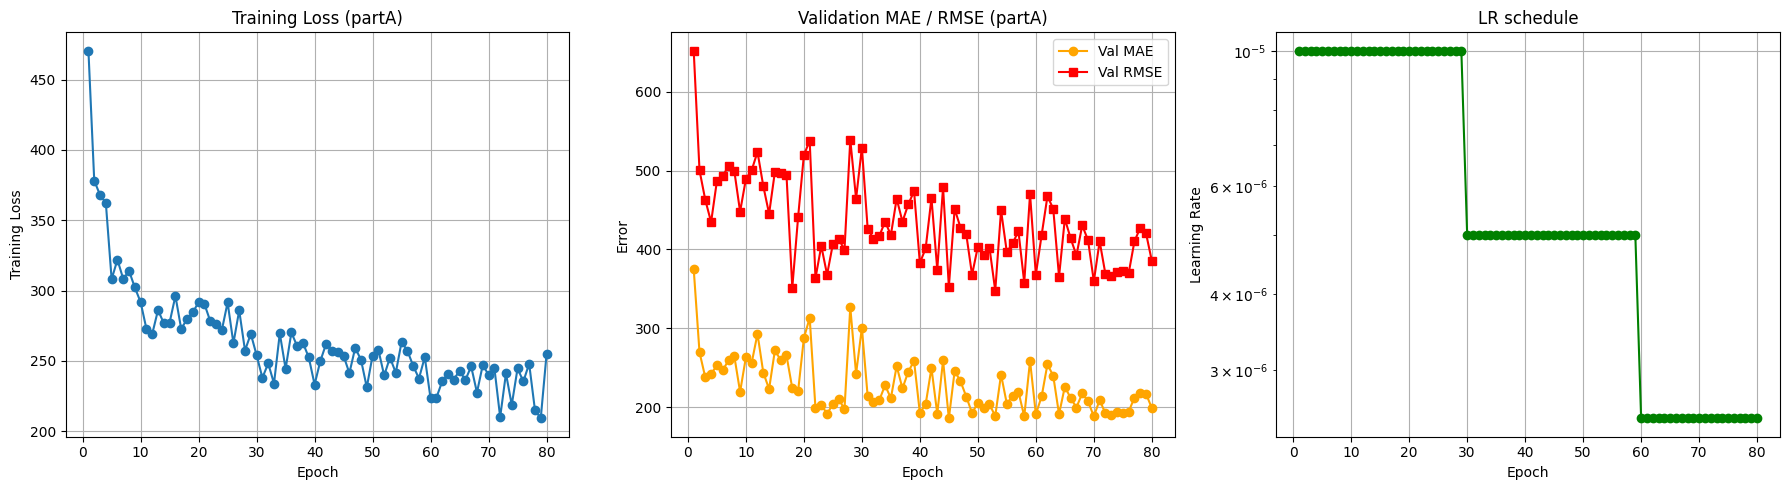

In [ ]:
# Training-curve plots
plots_dir = os.path.join(project_path, "results/plots")
os.makedirs(plots_dir, exist_ok=True)

epochs = list(range(1, len(train_losses) + 1))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, train_losses, marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training Loss")
axes[0].set_title(f"Training Loss ({PART_TAG})"); axes[0].grid(True)

axes[1].plot(epochs, val_maes, marker="o", color="orange", label="Val MAE")
axes[1].plot(epochs, val_rmses, marker="s", color="red", label="Val RMSE")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Error")
axes[1].set_title(f"Validation MAE / RMSE ({PART_TAG})"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs, lrs, marker="o", color="green")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log"); axes[2].set_title("LR schedule"); axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, f"training_curves_{PART_TAG}.png"), dpi=200, bbox_inches="tight")
plt.show()

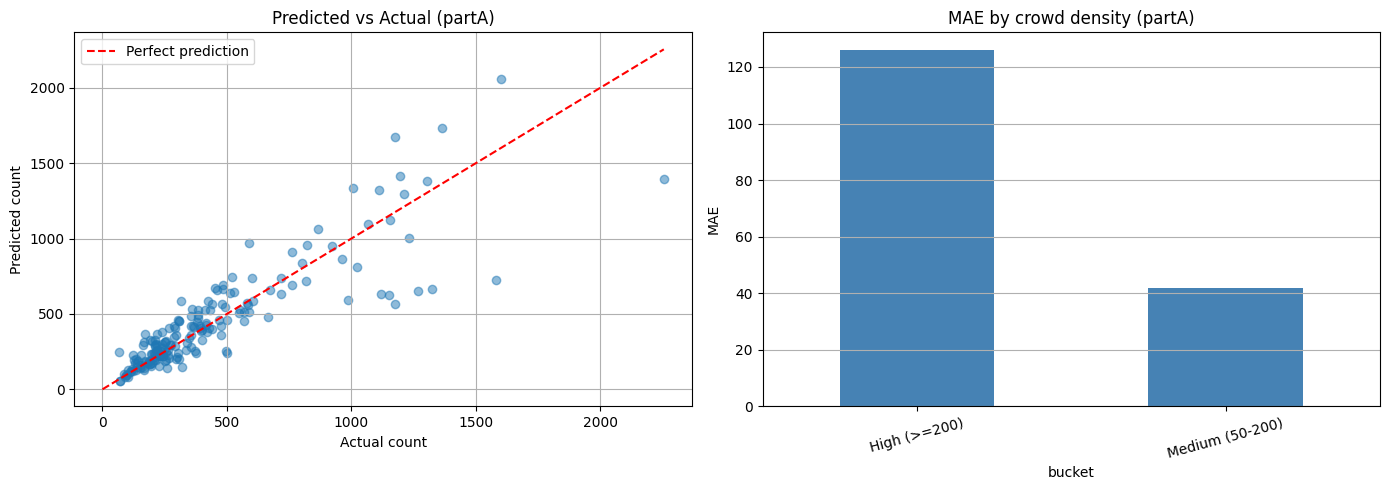

In [ ]:
# Scatter plot + bucket bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_df["actual"], pred_df["predicted"], alpha=0.5)
mx = max(pred_df["actual"].max(), pred_df["predicted"].max())
axes[0].plot([0, mx], [0, mx], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual count"); axes[0].set_ylabel("Predicted count")
axes[0].set_title(f"Predicted vs Actual ({PART_TAG})"); axes[0].legend(); axes[0].grid(True)

bucket_summary["MAE"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_ylabel("MAE"); axes[1].set_title(f"MAE by crowd density ({PART_TAG})")
axes[1].tick_params(axis="x", rotation=15); axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, f"error_analysis_{PART_TAG}.png"), dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Visualize best, average, worst predictions
def visualize_prediction(image_name, save=True):
    row = pred_df[pred_df["image"] == image_name].iloc[0]

    image = Image.open(os.path.join(test_img_dir, image_name)).convert("RGB")
    idx = test_dataset.data[test_dataset.data["image"] == image_name].index[0]
    image_tensor, gt_density, _, _ = test_dataset[idx]

    with torch.no_grad():
        pred_density = torch.clamp(
            model(image_tensor.unsqueeze(0).to(device)), min=0)

    # Both are scaled — divide by DENSITY_SCALE for display
    gt_np = gt_density.squeeze().cpu().numpy() / DENSITY_SCALE
    pred_np = pred_density.squeeze().cpu().numpy() / DENSITY_SCALE

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(image); axes[0].axis("off")
    axes[0].set_title(f"Original\nActual: {row['actual']:.0f}")
    axes[1].imshow(gt_np, cmap="jet"); axes[1].axis("off")
    axes[1].set_title(f"GT density\nSum: {gt_np.sum():.1f}")
    axes[2].imshow(pred_np, cmap="jet"); axes[2].axis("off")
    axes[2].set_title(f"Predicted\nSum: {row['predicted']:.1f}\nError: {row['abs_error']:.1f}")
    plt.tight_layout()

    if save:
        out_path = os.path.join(project_path, "results/predictions",
                                f"{PART_TAG}_{image_name.replace('.jpg', '_pred.png')}")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


print("\n=== Best predictions ===")
for name in pred_df.nsmallest(3, "abs_error")["image"]:
    visualize_prediction(name)

print("\n=== Average predictions ===")
median_err = pred_df["abs_error"].median()
for name in pred_df.iloc[(pred_df["abs_error"] - median_err).abs().argsort()[:3]]["image"]:
    visualize_prediction(name)

print("\n=== Worst predictions ===")
for name in pred_df.nlargest(3, "abs_error")["image"]:
    visualize_prediction(name)

Output hidden; open in https://colab.research.google.com to view.

---
## 10. Comparison table

> **Run after BOTH parts have been trained.** Loads both checkpoints and tabulates side-by-side with paper baselines.

In [ ]:
def load_test_metrics(part_tag):
    ckpt_path = os.path.join(project_path, "checkpoints", part_tag, f"csrnet_best_{part_tag}.pth")
    if not os.path.exists(ckpt_path):
        return None, None
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    p = "part_A_final" if part_tag == "partA" else "part_B_final"
    proc_base = os.path.join(project_path, "data/processed", p)
    raw_base = os.path.join(project_path, "data/raw/ShanghaiTech", p)

    test_ds = CrowdCountingDataset(
        csv_path=os.path.join(proc_base, "test_counts.csv"),
        image_dir=os.path.join(raw_base, "test_data/images"),
        density_dir=os.path.join(proc_base, "test_data/density_maps"),
        crop_size=(384, 512), output_downscale=8, augment=False,
        density_scale=DENSITY_SCALE)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

    m = CSRNet(load_pretrained=False).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return evaluate_model(m, test_loader, device)


partA_mae, partA_rmse = load_test_metrics("partA")
partB_mae, partB_rmse = load_test_metrics("partB")

def fmt(x):
    return f"{x:.2f}" if x is not None else "—"

comparison = pd.DataFrame([
    {"Method": "MCNN (Zhang 2016)",        "PartA_MAE": "110.2", "PartA_RMSE": "173.2", "PartB_MAE": "26.4", "PartB_RMSE": "41.3"},
    {"Method": "FCN (Marsden 2016)",       "PartA_MAE": "126.5", "PartA_RMSE": "173.5", "PartB_MAE": "23.8", "PartB_RMSE": "33.1"},
    {"Method": "SaCNN (Zhang 2017)",       "PartA_MAE":  "86.8", "PartA_RMSE": "139.2", "PartB_MAE": "16.2", "PartB_RMSE": "25.8"},
    {"Method": "CSRNet (Li 2018, paper)",  "PartA_MAE":  "68.2", "PartA_RMSE": "115.0", "PartB_MAE": "10.6", "PartB_RMSE": "16.0"},
    {"Method": "CSRNet (ours, extended)",
     "PartA_MAE": fmt(partA_mae), "PartA_RMSE": fmt(partA_rmse),
     "PartB_MAE": fmt(partB_mae), "PartB_RMSE": fmt(partB_rmse)},
])

comparison.to_csv(os.path.join(project_path, "results/comparison_table.csv"), index=False)
print(comparison.to_string(index=False))

                 Method PartA_MAE PartA_RMSE PartB_MAE PartB_RMSE
      MCNN (Zhang 2016)     110.2      173.2      26.4       41.3
     FCN (Marsden 2016)     126.5      173.5      23.8       33.1
     SaCNN (Zhang 2017)      86.8      139.2      16.2       25.8
CSRNet (Li 2018, paper)      68.2      115.0      10.6       16.0
CSRNet (ours, extended)    106.11     178.18     18.01      36.16


---
## 11. Demo — run on a custom image

In [ ]:
def predict_count(image_path, part_tag="partA"):
    """Run trained model on an image and visualize result."""
    ckpt_path = os.path.join(project_path, "checkpoints", part_tag, f"csrnet_best_{part_tag}.pth")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    m = CSRNet(load_pretrained=False).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()

    image = Image.open(image_path).convert("RGB")
    resized = image.resize((512, 384))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    x = transform(resized).unsqueeze(0).to(device)

    with torch.no_grad():
        density = torch.clamp(m(x), min=0)

    density_np = density.squeeze().cpu().numpy() / DENSITY_SCALE
    count = density_np.sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(image); axes[0].axis("off")
    axes[0].set_title(f"Input — Predicted: {round(count)} people")
    axes[1].imshow(density_np, cmap="jet"); axes[1].axis("off")
    axes[1].set_title(f"Density map — sum = {count:.2f}")
    plt.tight_layout()
    plt.show()
    return count

print("Demo function ready. Upload via Files tab, then call:")
print("  predict_count('/content/your_image.jpg', part_tag='partA')")

Demo function ready. Upload via Files tab, then call:
  predict_count('/content/your_image.jpg', part_tag='partA')


---
## Done

After running through this notebook for **both Part A and Part B**:

- `checkpoints/partA/csrnet_best_partA.pth` — best Part A model
- `checkpoints/partB/csrnet_best_partB.pth` — best Part B model
- `results/comparison_table.csv` — for the report
- `results/error_by_density_*.csv` — error analysis tables
- `results/plots/*.png` — training curves and error plots
- `results/predictions/*.png` — best/avg/worst examples

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

project_path = "/content/drive/MyDrive/crowd-counting-csrnet"

df = pd.read_csv(os.path.join(project_path, "results/test_predictions_partA.csv"))
print(f"Total Part A test images: {len(df)}")
print(f"Min actual count: {df['actual'].min()}")
print(f"Max actual count: {df['actual'].max()}")
print(f"Images under 50 people: {(df['actual'] < 50).sum()}")

# Also print the bucket tables
print("\n--- Part A buckets ---")
print(pd.read_csv(os.path.join(project_path, "results/error_by_density_partA.csv")))

print("\n--- Part B buckets ---")
print(pd.read_csv(os.path.join(project_path, "results/error_by_density_partB.csv")))

Total Part A test images: 182
Min actual count: 66.0
Max actual count: 2256.0
Images under 50 people: 0

--- Part A buckets ---
            bucket    n  mean_actual     MAE    RMSE  mean_rel_err_pct
0     High (>=200)  139       523.38  125.95  200.56             23.10
1  Medium (50-200)   43       144.65   41.96   65.99             31.25

--- Part B buckets ---
            bucket    n  mean_actual    MAE   RMSE  mean_rel_err_pct
0     High (>=200)   50       295.86  55.74  82.61             16.05
1        Low (<50)   60        35.73   3.32   4.64              9.12
2  Medium (50-200)  206       108.11  13.13  18.51             11.94


In [ ]:
import os, pandas as pd
project_path = "/content/drive/MyDrive/crowd-counting-csrnet"
df = pd.read_csv(os.path.join(project_path, "results/test_predictions_partB.csv"))

best = df.nsmallest(1, "abs_error").iloc[0]
worst = df.nlargest(1, "abs_error").iloc[0]
median_err = df["abs_error"].median()
median = df.iloc[(df["abs_error"] - median_err).abs().argsort()[:1]].iloc[0]

for label, row in [("BEST", best), ("MEDIAN", median), ("WORST", worst)]:
    fname = f"partB_{row['image'].replace('.jpg', '_pred.png')}"
    print(f"{label}: {fname}  (actual={row['actual']:.0f}, predicted={row['predicted']:.1f}, error={row['abs_error']:.1f})")

BEST: partB_IMG_133_pred.png  (actual=137, predicted=137.1, error=0.1)
MEDIAN: partB_IMG_230_pred.png  (actual=93, predicted=85.4, error=7.6)
WORST: partB_IMG_75_pred.png  (actual=539, predicted=267.6, error=271.4)


In [2]:
import os, pandas as pd

project_path = "/content/drive/MyDrive/crowd-counting-csrnet"

# Comparison table
print("=== Final comparison ===")
print(pd.read_csv(os.path.join(project_path, "results/comparison_table.csv")))

# Bucket analysis
print("\n=== Part A buckets ===")
print(pd.read_csv(os.path.join(project_path, "results/error_by_density_partA.csv")))

print("\n=== Part B buckets ===")
print(pd.read_csv(os.path.join(project_path, "results/error_by_density_partB.csv")))

# Best/worst examples used in report
df_b = pd.read_csv(os.path.join(project_path, "results/test_predictions_partB.csv"))
print("\n=== Best/Worst Part B (sanity check vs report) ===")
print(f"Best:  {df_b.nsmallest(1, 'abs_error').iloc[0].to_dict()}")
print(f"Worst: {df_b.nlargest(1, 'abs_error').iloc[0].to_dict()}")

=== Final comparison ===
                    Method  PartA_MAE  PartA_RMSE  PartB_MAE  PartB_RMSE
0        MCNN (Zhang 2016)     110.20      173.20      26.40       41.30
1       FCN (Marsden 2016)     126.50      173.50      23.80       33.10
2       SaCNN (Zhang 2017)      86.80      139.20      16.20       25.80
3  CSRNet (Li 2018, paper)      68.20      115.00      10.60       16.00
4  CSRNet (ours, extended)     106.11      178.18      18.01       36.16

=== Part A buckets ===
            bucket    n  mean_actual     MAE    RMSE  mean_rel_err_pct
0     High (>=200)  139       523.38  125.95  200.56             23.10
1  Medium (50-200)   43       144.65   41.96   65.99             31.25

=== Part B buckets ===
            bucket    n  mean_actual    MAE   RMSE  mean_rel_err_pct
0     High (>=200)   50       295.86  55.74  82.61             16.05
1        Low (<50)   60        35.73   3.32   4.64              9.12
2  Medium (50-200)  206       108.11  13.13  18.51             11.94
